# MPA-MLF — Final Project
## Room Occupancy Classification from 60 GHz Radar Snapshots

**Objectif :** Classifier le nombre de personnes dans une pièce (0, 1, 2 ou 3) à partir de snapshots radar dans le domaine delay-Doppler.

**Pipeline général :**
1. Chargement & exploration des données
2. Prétraitement & augmentation
3. Construction du modèle CNN
4. Entraînement avec callbacks
5. Évaluation & analyse des erreurs
6. Génération du fichier de soumission Kaggle

In [12]:
import os

zip_path = "/content/MPA_MLF_final_project2026.zip"

if os.path.exists(zip_path):
    print(f"Le fichier '{zip_path}' existe.")
else:
    print(f"Le fichier '{zip_path}' n'existe PAS. Veuillez vérifier le chemin et le nom du fichier.")

Le fichier '/content/MPA_MLF_final_project2026.zip' existe.


In [13]:
import zipfile

zip_path = "/content/MPA_MLF_final_project2026.zip"
extract_path = "/content/data_bon"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction terminée !")

Extraction terminée !


In [14]:
import zipfile

zip_path = "/content/data_bon/MPA_MLF_final_project2026/x_test.zip"
extract_path = "/content/data_bon/MPA_MLF_final_project2026/x_test"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction terminée !")

Extraction terminée !


In [15]:
import zipfile

zip_path = "/content/data_bon/MPA_MLF_final_project2026/x_train.zip"
extract_path = "/content/data_bon/MPA_MLF_final_project2026/x_train"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction terminée !")

Extraction terminée !


## 0. Installation des dépendances

In [16]:
# Sur Google Colab uniquement — décommenter si nécessaire
# !pip install tensorflow scikit-learn matplotlib seaborn pandas numpy Pillow

## 1. Imports & Configuration

In [17]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuration générale
IMG_SIZE = (64, 64)   # taille de redimensionnement
BATCH_SIZE = 32
EPOCHS = 60
NUM_CLASSES = 4

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU disponible : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.19.0
GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Chargement des données

> **Important (consigne du projet) :** Les images sont numérotées à partir de **1**, mais les labels dans `y_train.csv` sont indexés à partir de **0**. Il faut donc décaler l'index lors de la jointure.

In [18]:
# ----- Adapter ces chemins selon votre environnement -----
TRAIN_DIR = Path("/content/data_bon/MPA_MLF_final_project2026/x_train")   # dossier extrait de x_train.zip
TEST_DIR  = Path("/content/data_bon/MPA_MLF_final_project2026/x_test")    # dossier extrait de x_test.zip
Y_TRAIN_CSV = Path("/content/data_bon/MPA_MLF_final_project2026/y_train_v2.csv")
Y_TEST_EXAMPLE = Path("/content/data_bon/MPA_MLF_final_project2026/y_test_submission_example_v2.csv")

# Décompresser si nécessaire
def extract_if_needed(zip_path, dest):
    if not dest.exists():
        print(f"Extraction de {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(dest.parent)
        print("Terminé.")
    else:
        print(f"{dest} déjà extrait.")

extract_if_needed(Path("/content/data_bon/MPA_MLF_final_project2026/x_train.zip"), TRAIN_DIR)
extract_if_needed(Path("/content/data_bon/MPA_MLF_final_project2026/x_test.zip"),  TEST_DIR)

/content/data_bon/MPA_MLF_final_project2026/x_train déjà extrait.
/content/data_bon/MPA_MLF_final_project2026/x_test déjà extrait.


In [19]:
def load_images_from_dir(directory, img_size):
    """
    Charge toutes les images PNG d'un dossier.
    Retourne un tableau numpy (N, H, W, 3) et la liste des IDs (entiers).
    """
    directory = Path(directory)
    files = sorted(directory.glob("*.png"), key=lambda p: int(p.stem.split('_')[-1]))
    images, ids = [], []
    for f in files:
        img = Image.open(f).convert("RGB").resize(img_size)
        images.append(np.array(img, dtype=np.float32) / 255.0)
        ids.append(int(f.stem.split('_')[-1]))
    return np.array(images), ids

print("Chargement des images d'entraînement...")
X_all, train_ids = load_images_from_dir(TRAIN_DIR, IMG_SIZE)
print(f"  → {X_all.shape[0]} images chargées, shape : {X_all.shape}")

print("Chargement des images de test...")
X_test_raw, test_ids = load_images_from_dir(TEST_DIR, IMG_SIZE)
print(f"  → {X_test_raw.shape[0]} images de test, shape : {X_test_raw.shape}")

Chargement des images d'entraînement...
  → 9227 images chargées, shape : (9227, 64, 64, 3)
Chargement des images de test...
  → 3955 images de test, shape : (3955, 64, 64, 3)


In [20]:
# Chargement des labels
# ATTENTION : labels indexés à partir de 0, images à partir de 1
df_labels = pd.read_csv(Y_TRAIN_CSV)
print(df_labels.head())
print(f"Colonnes : {df_labels.columns.tolist()}")
print(f"Distribution des classes :\n{df_labels.iloc[:, 1].value_counts().sort_index()}")

   id  target
0   0       0
1   1       1
2   2       0
3   3       2
4   4       2
Colonnes : ['id', 'target']
Distribution des classes :
target
0    1462
1    3786
2    3002
3     977
Name: count, dtype: int64


In [21]:
# Alignement images <-> labels
# Hypothèse : la 1ère colonne = index (0-based), la 2e = label
label_col = df_labels.columns[1]
id_col    = df_labels.columns[0]

# Construire un dict {image_id_1based -> label}
# image 1 = label[0], image 2 = label[1], ...
label_map = {row[id_col] + 1: row[label_col] for _, row in df_labels.iterrows()}

y_all = np.array([label_map[i] for i in train_ids])
print(f"Labels shape : {y_all.shape}")
print(f"Classes uniques : {np.unique(y_all)}")

Labels shape : (9227,)
Classes uniques : [0 1 2 3]


## 3. Exploration des données (EDA)

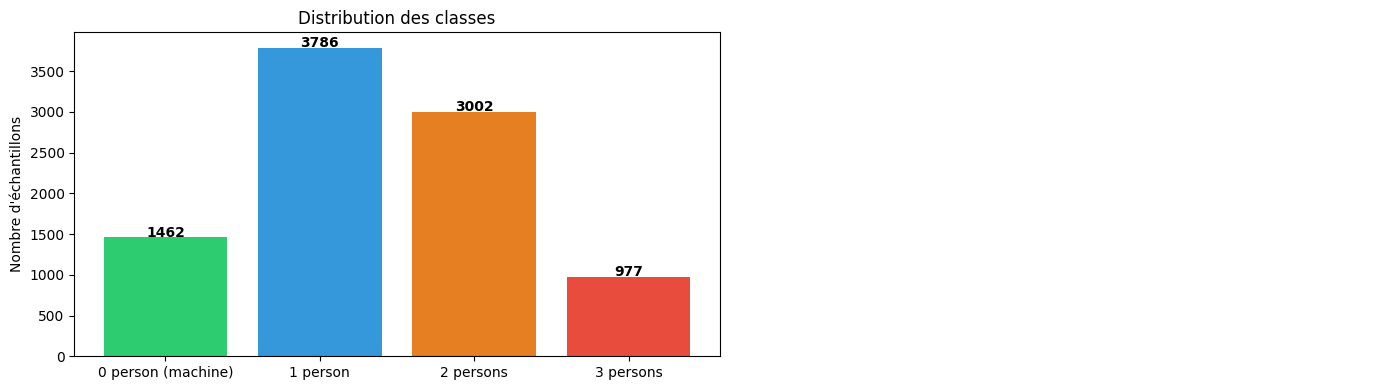

In [22]:
CLASS_NAMES = ["0 person (machine)", "1 person", "2 persons", "3 persons"]

# Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = np.bincount(y_all)
axes[0].bar(CLASS_NAMES, counts, color=['#2ecc71','#3498db','#e67e22','#e74c3c'])
axes[0].set_title("Distribution des classes")
axes[0].set_ylabel("Nombre d'échantillons")
for i, c in enumerate(counts):
    axes[0].text(i, c + 5, str(c), ha='center', fontweight='bold')

# Exemples d'images par classe
axes[1].axis('off')
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120, bbox_inches='tight')
plt.show()

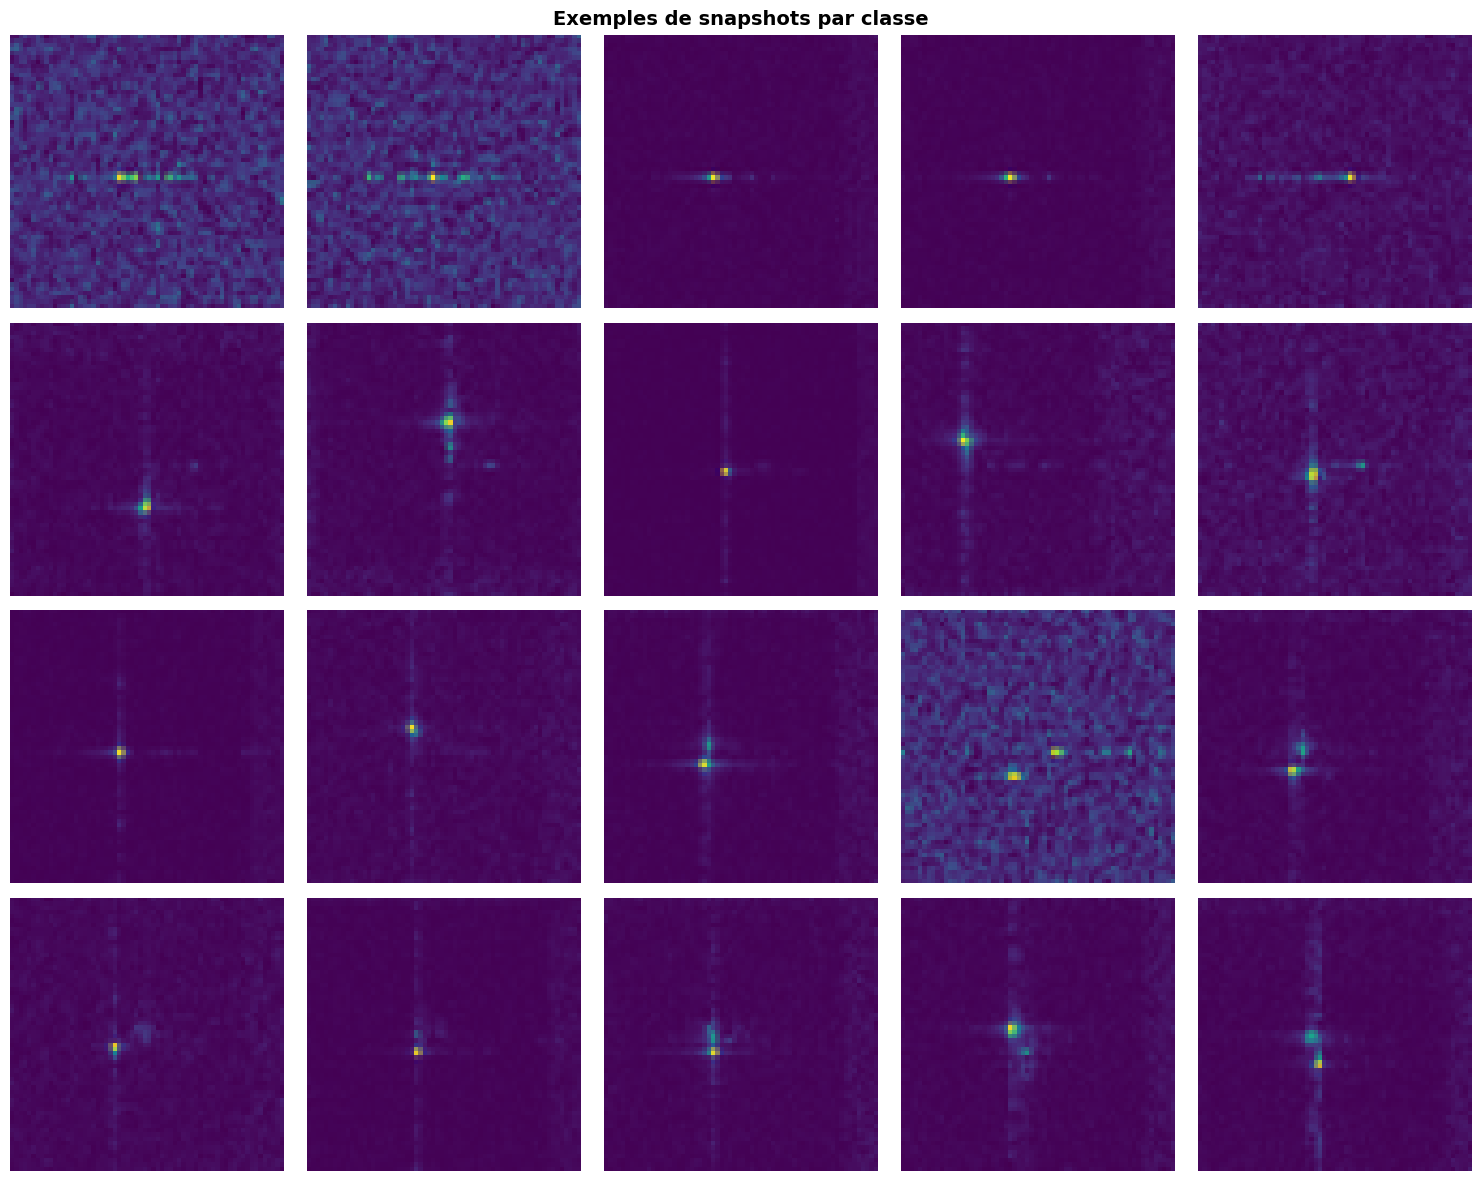

In [23]:
# Affichage d'exemples par classe
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, 12))
fig.suptitle("Exemples de snapshots par classe", fontsize=14, fontweight='bold')

for cls in range(NUM_CLASSES):
    indices = np.where(y_all == cls)[0]
    sample_idx = np.random.choice(indices, size=5, replace=False)
    for j, idx in enumerate(sample_idx):
        axes[cls, j].imshow(X_all[idx])
        axes[cls, j].axis('off')
        if j == 0:
            axes[cls, j].set_ylabel(CLASS_NAMES[cls], fontsize=9, rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig("sample_images_per_class.png", dpi=120, bbox_inches='tight')
plt.show()

## 4. Split Train / Validation

In [24]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.15,
    stratify=y_all,
    random_state=SEED
)

print(f"Entraînement : {X_train.shape[0]} images")
print(f"Validation   : {X_val.shape[0]} images")
print(f"Test         : {X_test_raw.shape[0]} images")

Entraînement : 7842 images
Validation   : 1385 images
Test         : 3955 images


## 5. Augmentation de données

Pour améliorer la généralisation, on applique des transformations géométriques légères. On évite les flips horizontaux agressifs car la position spatiale dans le delay-Doppler a une signification physique.

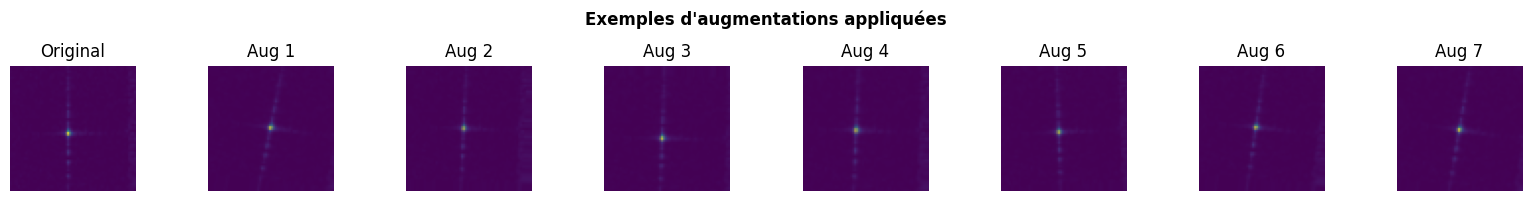

In [25]:
# Augmentation uniquement sur le train set
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=False,   # physiquement non pertinent sur delay-Doppler
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()  # pas d'augmentation en validation

train_generator = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_generator   = val_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)

# Visualisation de quelques augmentations
sample_img = X_train[0:1]
aug_iter = train_datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample_img[0]); axes[0].set_title("Original"); axes[0].axis('off')
for i in range(1, 8):
    aug = next(aug_iter)[0]
    axes[i].imshow(aug); axes[i].set_title(f"Aug {i}"); axes[i].axis('off')
plt.suptitle("Exemples d'augmentations appliquées", fontweight='bold')
plt.tight_layout()
plt.savefig("augmentation_examples.png", dpi=100, bbox_inches='tight')
plt.show()

## 6. Architecture du modèle — CNN personnalisé

On utilise un CNN avec :
- Blocs Conv + BatchNorm + MaxPool progressifs
- Dropout pour la régularisation
- Classification finale via Dense + Softmax

Ce type d'architecture est bien adapté aux images 2D comme les spectrogrammes ou snapshots radar.

In [26]:
def build_cnn(input_shape=(64, 64, 3), num_classes=4):
    inputs = keras.Input(shape=input_shape)

    # Bloc 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.25)(x)

    # Bloc 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.25)(x)

    # Bloc 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.3)(x)

    # Tête de classification
    x = layers.GlobalAveragePooling2D()(x)  # plus robuste que Flatten
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="RoomOccupancy_CNN")
    return model

model = build_cnn(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
model.summary()

Model: "RoomOccupancy_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 323,876 (1.24 MB)

 Trainable params: 322,468 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 7. Compilation & Callbacks

In [27]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Modèle compilé et callbacks configurés.")

Modèle compilé et callbacks configurés.


## 8. Entraînement

In [28]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print(f"\nEntraînement terminé après {len(history.history['loss'])} époques.")

Epoch 1/60
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.3879 - loss: 1.5715
Epoch 1: val_accuracy improved from None to 0.15812, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 36s 86ms/step - accuracy: 0.4792 - loss: 1.3087 - val_accuracy: 0.1581 - val_loss: 11.1924 - learning_rate: 0.0010
Epoch 2/60
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6368 - loss: 0.8971
Epoch 2: val_accuracy improved from 0.15812 to 0.21155, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.6423 - loss: 0.8647 - val_accuracy: 0.2116 - val_loss: 7.0442 - learning_rate: 0.0010
Epoch 3/60
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6626 - loss: 0.7952
Epoch 3: val_accuracy improved from 0.21155 to 0.70542, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 14s

## 9. Courbes d'apprentissage

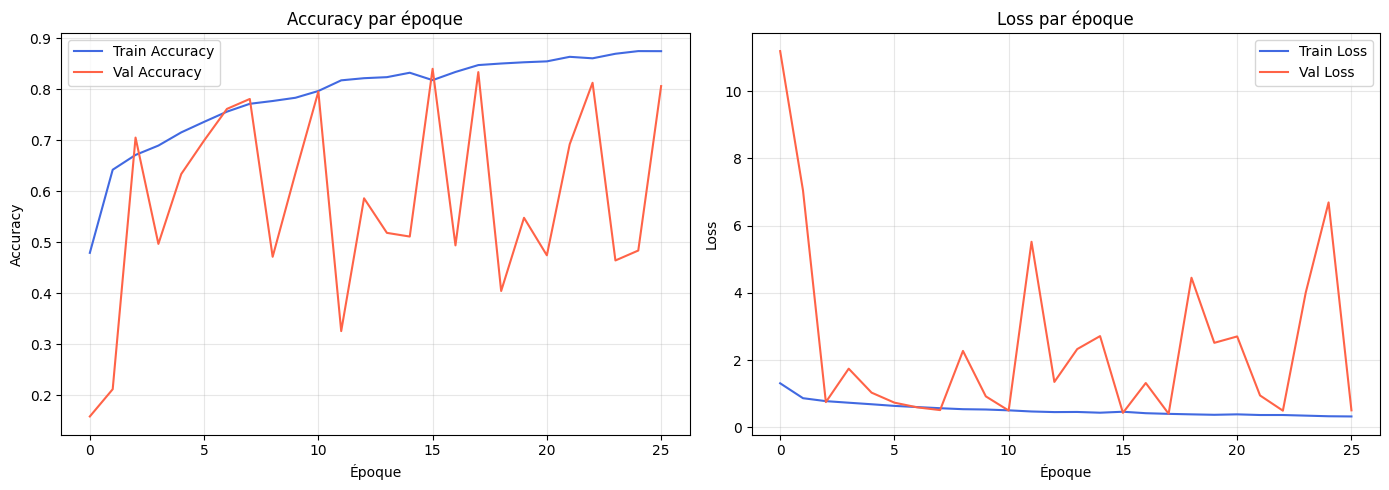

In [29]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='royalblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato')
    axes[0].set_title('Accuracy par époque')
    axes[0].set_xlabel('Époque')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='royalblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato')
    axes[1].set_title('Loss par époque')
    axes[1].set_xlabel('Époque')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("learning_curves.png", dpi=120, bbox_inches='tight')
    plt.show()

plot_history(history)

## 10. Évaluation sur le set de validation

In [30]:
# Charger le meilleur modèle sauvegardé
best_model = keras.models.load_model('best_model.keras')

val_loss, val_acc = best_model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")

Validation Accuracy : 0.8404
Validation Loss     : 0.4285


In [31]:
# Prédictions et rapport de classification
y_pred_proba = best_model.predict(X_val, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\n=== Rapport de classification ===")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES))


=== Rapport de classification ===
                    precision    recall  f1-score   support

0 person (machine)       0.98      1.00      0.99       219
          1 person       0.84      0.86      0.85       568
         2 persons       0.84      0.75      0.79       451
         3 persons       0.67      0.81      0.73       147

          accuracy                           0.84      1385
         macro avg       0.83      0.85      0.84      1385
      weighted avg       0.84      0.84      0.84      1385



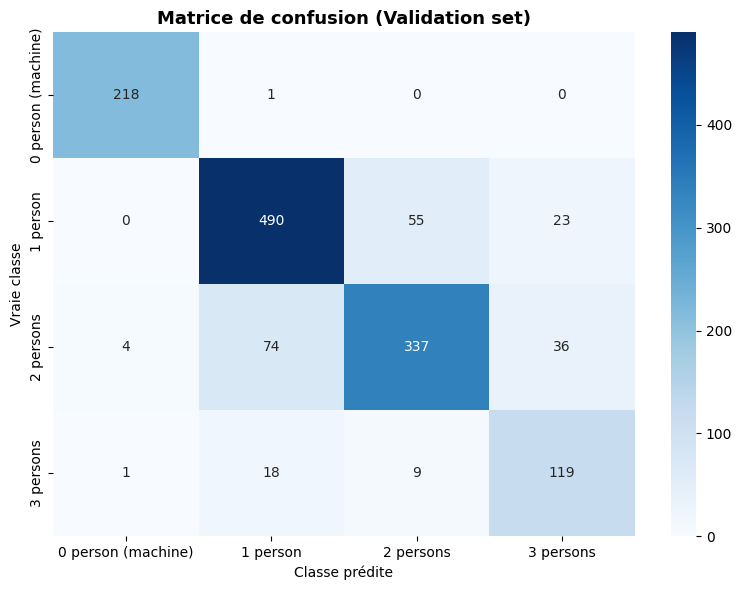

In [32]:
# Matrice de confusion
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Matrice de confusion (Validation set)', fontsize=13, fontweight='bold')
ax.set_ylabel('Vraie classe')
ax.set_xlabel('Classe prédite')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.show()

Nombre d'erreurs sur la validation : 221 / 1385


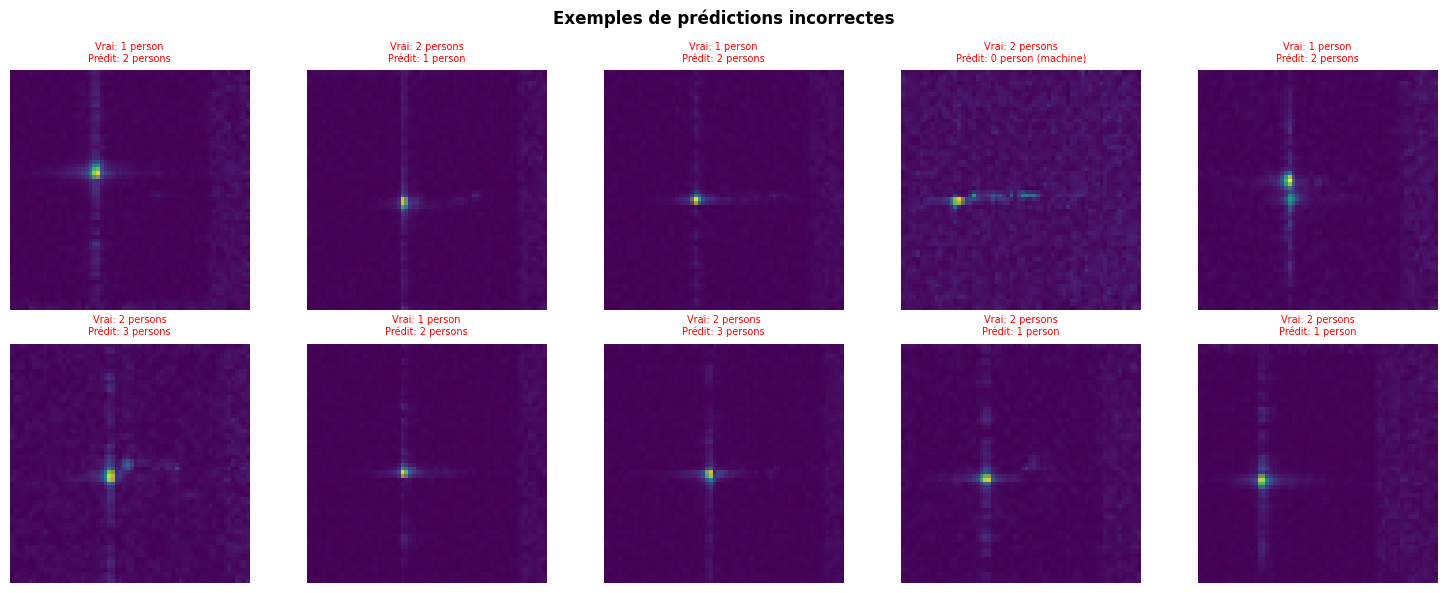

In [33]:
# Analyse des erreurs — afficher des cas mal classifiés
errors = np.where(y_pred != y_val)[0]
print(f"Nombre d'erreurs sur la validation : {len(errors)} / {len(y_val)}")

if len(errors) > 0:
    n_show = min(10, len(errors))
    sample_errors = np.random.choice(errors, n_show, replace=False)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    for i, idx in enumerate(sample_errors):
        axes[i].imshow(X_val[idx])
        axes[i].set_title(f"Vrai: {CLASS_NAMES[y_val[idx]]}\nPrédit: {CLASS_NAMES[y_pred[idx]]}",
                          fontsize=7, color='red')
        axes[i].axis('off')
    plt.suptitle("Exemples de prédictions incorrectes", fontweight='bold')
    plt.tight_layout()
    plt.savefig("error_analysis.png", dpi=100, bbox_inches='tight')
    plt.show()

## 11. (Optionnel) Transfer Learning avec MobileNetV2

Pour potentiellement améliorer les performances, on peut tester le transfer learning avec MobileNetV2 pré-entraîné sur ImageNet. Les features basses fréquences (textures, bords) sont utiles même pour des images radar colorisées.

In [34]:
def build_transfer_model(input_shape=(64, 64, 3), num_classes=4):
    base = keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    # Phase 1 : geler la base
    base.trainable = False

    inputs  = keras.Input(shape=input_shape)
    # MobileNetV2 attend des inputs dans [-1, 1]
    x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="MobileNetV2_Transfer")
    return model, base

tl_model, base_model = build_transfer_model(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
tl_model.summary()

/tmp/ipykernel_2371/353345831.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [35]:
# Phase 1 — entraîner uniquement la tête
tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tl_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6),
    ModelCheckpoint('best_tl_model.keras', monitor='val_accuracy', save_best_only=True)
]

history_tl = tl_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=tl_callbacks,
    verbose=1
)

Epoch 1/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 54s 151ms/step - accuracy: 0.6028 - loss: 0.9156 - val_accuracy: 0.6715 - val_loss: 0.7386 - learning_rate: 0.0010
Epoch 2/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.6552 - loss: 0.7820 - val_accuracy: 0.6989 - val_loss: 0.6843 - learning_rate: 0.0010
Epoch 3/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.6630 - loss: 0.7499 - val_accuracy: 0.6845 - val_loss: 0.7250 - learning_rate: 0.0010
Epoch 4/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.6704 - loss: 0.7432 - val_accuracy: 0.7076 - val_loss: 0.6370 - learning_rate: 0.0010
Epoch 5/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.6748 - loss: 0.7241 - val_accuracy: 0.7040 - val_loss: 0.6513 - learning_rate: 0.0010
Epoch 6/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.6801 - loss: 0.7127 - val_accuracy: 0.7148 - val_loss: 0.6312 - learning_rate: 0.0010
Epoch 7/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.6784 - 

In [36]:
# Phase 2 — fine-tuning : dégeler les dernières couches de la base
base_model.trainable = True
# Geler tout sauf les 30 dernières couches
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),   # LR très faible pour le fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = tl_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
        ModelCheckpoint('best_tl_model.keras', monitor='val_accuracy', save_best_only=True)
    ],
    verbose=1
)

# Évaluation du modèle transfer learning
best_tl = keras.models.load_model('best_tl_model.keras')
tl_loss, tl_acc = best_tl.evaluate(X_val, y_val, verbose=0)
print(f"Transfer Learning Val Accuracy : {tl_acc:.4f}")

Epoch 1/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 42s 107ms/step - accuracy: 0.5241 - loss: 2.1627 - val_accuracy: 0.6484 - val_loss: 0.7898
Epoch 2/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.5648 - loss: 1.2286 - val_accuracy: 0.6440 - val_loss: 0.8347
Epoch 3/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.5886 - loss: 0.9737 - val_accuracy: 0.6325 - val_loss: 0.8431
Epoch 4/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.6086 - loss: 0.9361 - val_accuracy: 0.5913 - val_loss: 0.8955
Epoch 5/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.6243 - loss: 0.8628 - val_accuracy: 0.6339 - val_loss: 0.8081
Epoch 6/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.6321 - loss: 0.8411 - val_accuracy: 0.6563 - val_loss: 0.7658
Epoch 7/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.6391 - loss: 0.8047 - val_accuracy: 0.6657 - val_loss: 0.7280
Epoch 8/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.6489 - loss: 0.8000 -

## 12. Sélection du meilleur modèle & Soumission Kaggle

In [37]:
# Comparer les deux modèles et choisir le meilleur
cnn_acc = best_model.evaluate(X_val, y_val, verbose=0)[1]
tl_acc  = best_tl.evaluate(X_val, y_val, verbose=0)[1]

print(f"CNN personnalisé  — Val Accuracy : {cnn_acc:.4f}")
print(f"Transfer Learning — Val Accuracy : {tl_acc:.4f}")

final_model = best_tl if tl_acc >= cnn_acc else best_model
print(f"\n→ Modèle retenu : {'Transfer Learning' if tl_acc >= cnn_acc else 'CNN personnalisé'}")

CNN personnalisé  — Val Accuracy : 0.8404
Transfer Learning — Val Accuracy : 0.7350

→ Modèle retenu : CNN personnalisé


In [38]:
# Génération des prédictions sur le test set
y_test_proba = final_model.predict(X_test_raw, verbose=0)
y_test_pred  = np.argmax(y_test_proba, axis=1)

print(f"Prédictions générées pour {len(y_test_pred)} images de test.")
print(f"Distribution des prédictions : {dict(zip(*np.unique(y_test_pred, return_counts=True)))}")

Prédictions générées pour 3955 images de test.
Distribution des prédictions : {np.int64(0): np.int64(596), np.int64(1): np.int64(1680), np.int64(2): np.int64(1157), np.int64(3): np.int64(522)}


In [39]:
# Création du fichier de soumission au format Kaggle
# NOTE : les images de test sont numérotées à partir de 1,
#        les labels de soumission sont indexés à partir de 0 (index = image_id - 1)
submission_example = pd.read_csv(Y_TEST_EXAMPLE)
print("Format attendu :")
print(submission_example.head())
print(f"Colonnes : {submission_example.columns.tolist()}")

Format attendu :
     id  target
0  9227       0
1  9228       3
2  9229       2
3  9230       3
4  9231       3
Colonnes : ['id', 'target']


In [40]:
# Construire le DataFrame de soumission
id_col_name    = submission_example.columns[0]
label_col_name = submission_example.columns[1]

submission_df = pd.DataFrame({
    id_col_name:    [i - 1 for i in test_ids],    # index 0-based
    label_col_name: y_test_pred
})

submission_df.to_csv("submission.csv", index=False)
print("✅ Fichier submission.csv généré !")
print(submission_df.head(10))

✅ Fichier submission.csv généré !
     id  target
0  9227       1
1  9228       2
2  9229       0
3  9230       0
4  9231       3
5  9232       1
6  9233       1
7  9234       1
8  9235       2
9  9236       3


## 13. Résumé des résultats

In [41]:
print("=" * 55)
print("         RÉSUMÉ DES PERFORMANCES")
print("=" * 55)
print(f"CNN personnalisé  — Val Accuracy : {cnn_acc*100:.2f}%")
print(f"Transfer Learning — Val Accuracy : {tl_acc*100:.2f}%")
print("-" * 55)
print(f"Modèle final retenu : {'Transfer Learning (MobileNetV2)' if tl_acc >= cnn_acc else 'CNN personnalisé'}")
print("=" * 55)
print()
print("Fichiers générés :")
print("  - best_model.keras       → meilleur CNN personnalisé")
print("  - best_tl_model.keras    → meilleur modèle Transfer Learning")
print("  - submission.csv         → soumission Kaggle")
print("  - learning_curves.png    → courbes d'entraînement")
print("  - confusion_matrix.png   → matrice de confusion")
print("  - error_analysis.png     → analyse des erreurs")

         RÉSUMÉ DES PERFORMANCES
CNN personnalisé  — Val Accuracy : 84.04%
Transfer Learning — Val Accuracy : 73.50%
-------------------------------------------------------
Modèle final retenu : CNN personnalisé

Fichiers générés :
  - best_model.keras       → meilleur CNN personnalisé
  - best_tl_model.keras    → meilleur modèle Transfer Learning
  - submission.csv         → soumission Kaggle
  - learning_curves.png    → courbes d'entraînement
  - confusion_matrix.png   → matrice de confusion
  - error_analysis.png     → analyse des erreurs
